# Convolution Neural Networks

- Convolution: Revealing only useful characteristics from input data
    - The output created through convolution calculation is called a feature map.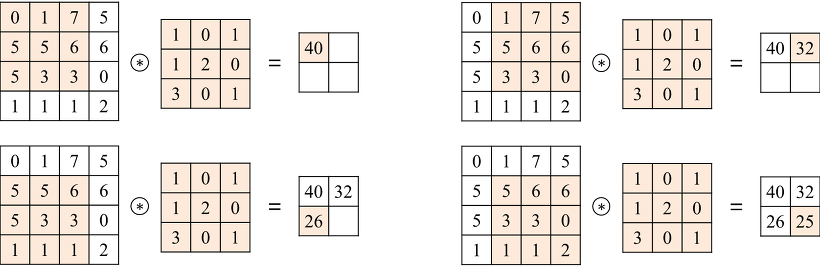

- In general, an artificial neural network using one or more convolutional layers is called a convolutional neural network.
    - It is not a neural network using only convolutional layers.
    
- Difference between convolution and dense layer
    - In the dense layer, each unit has a weight equivalent to the number of inputs.
    - Convolution multiplies a portion of the input data by a weight.
    - In convolutional neural networks, units are called filters or kernels.
    
- If the input data is a two-dimensional array, the filter must also be two-dimensional.
- In the image above, the kernel size is (3, 3)
- Just as multiple units are used in the dense layer, multiple filters can be used in the convolutional layer.
- Convolution maintains a two-dimensional shape
    - Excellent performance in image processing because it can reduce the loss of spatial characteristics
    
- Convolution operation order
    1. Start convolution from the upper left corner
    2. Calculate 1 output
    3. Move to the right
        - If you can't move to the right, move down
    4. Repeat steps 2 to 3 to perform the convolution operation.

In [5]:
from tensorflow import keras

In [6]:
# convolutional layer
keras.layers.Conv2D(10, kernel_size=(3, 3), activation="relu", padding="same", strides=1)

- The first parameter of Conv2D is the number of filters (required)
- kernel_size: Size of filter (required)
    - Generally used in sizes of (3,3) or (5,5)
    
- Activation function
    - In a convolutional neural network, the feature map is the result after applying the intercept and activation function.

## Padding
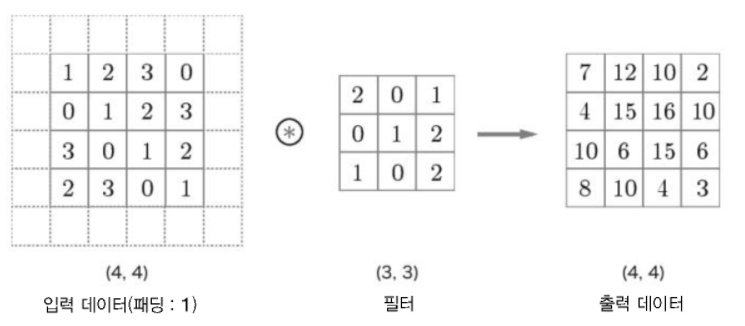

- Filling the area around the input array with virtual elements
- When passing through the convolution layer, the size of the output becomes smaller than the size of the input data. This is used to prevent this.
    - Calculate as if an input greater than (4, 4) was received.
    - If you perform a convolution operation on data of (6, 6) with a kernel of size (3, 3), the size of the output will remain at (4, 4).
    
- Since it is not actually an input value, the padding is filled with 0.
    - Does not affect calculations because the values ​​are filled with 0
    
- Same padding: Padding with 0 around the input data to make the size of the input and feature map the same.
    - Generally, seam padding is used a lot.

- Valid padding: Creating a feature map by performing convolution only on the pure input array without padding.
    - The size of the feature map is reduced compared to the input.
    
- Why use padding?
    - If padding is not used, the use ratio of the elements in the center of the input value and the corners are significantly different.
    - Appropriate use of padding can prevent loss of information around the image.

## Stride
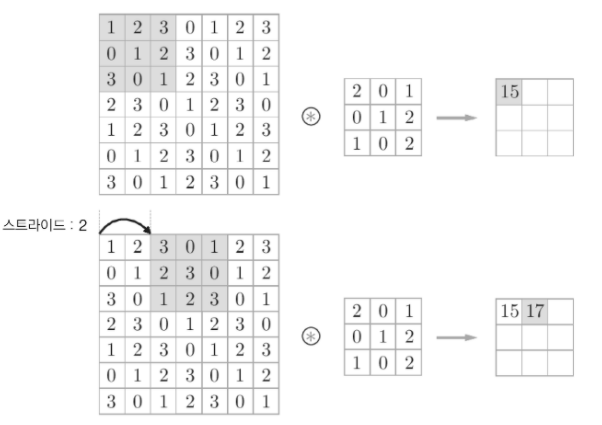

- Interval of positions where kernels are applied (size of movement)
- Default is 1
    - The size of the movement to the right and the size of the movement downward can also be specified as a tuple, such as (1, 1).
    - However, in general, the horizontal and vertical sizes are specified to be equal.
    - It was rare to use a stride greater than 1.
        - Recently, methods of increasing stride without using maxpooling have been increasingly introduced.

## Pooling
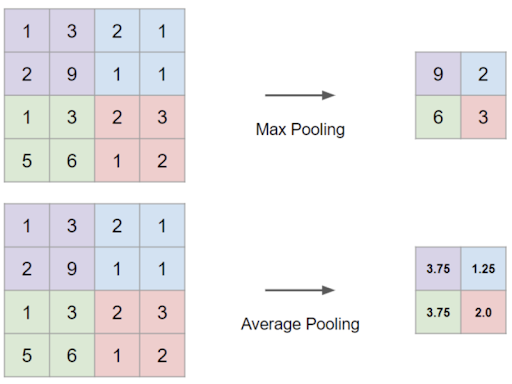

- Plays the role of reducing the horizontal and vertical sizes of the feature map created in the convolution layer.
    - The number of characteristic maps does not change.
    
- Used to reduce the amount of calculation while maintaining the features extracted from the convolution layer and to easily connect to the next layer neural network.
- Pooling has no weights and calculates the maximum value (max pooling) or the average value (average pooling).
    - max pooling is used more than average pooling
    - Average pooling is because important information in the feature map may be diluted during the average calculation process.
    
- Convolution has overlapping kernels, but pooling moves without overlapping.
- Recently, a method of reducing the use of pooling layers has been introduced to prevent the loss of fine but important features as neural networks become deeper.
    - However, pooling is still a useful neural network layer for maintaining good performance with a small amount of computation.

In [7]:
# pooling
keras.layers.MaxPool2D(2, strides=2, padding="valid")

- The first parameter of MaxPool2D is the size of the pooling.
    - Typically use 2 (reduces the horizontal and vertical sizes by half)
    - If you want to vary the pooling size in the horizontal and vertical directions, you can input it as a tuple, but it is very rarely used in practice.
        - ex. (2, 3)
        
- strides: There is no need to specify it separately because the pooling size is automatically entered.
- padding: Default is valid. Generally use valid
    - valid: Ignored if the remaining edge does not match the pool_size
    - same: Process after adjusting size by adding 0 value

# Structure of a CNN
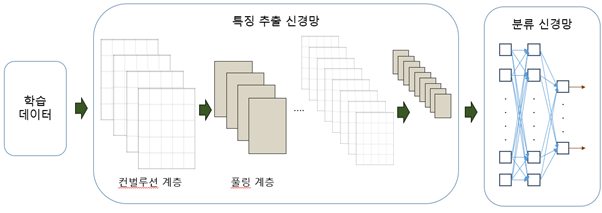

- Convolutional neural networks are characterized by gradually decreasing width and height and gradually increasing depth.
- In the final classification neural network, all feature maps are spread out and used as input to the dense layer.
- In a convolutional neural network, a filter is responsible for finding certain features in the image.
    - As the number of filters increases and the layers become deeper, specific features of the data are detected.
    - Compress (pooling) the width and height so that any feature can be easily detected no matter where it is located in the image.

# Convolution using color images
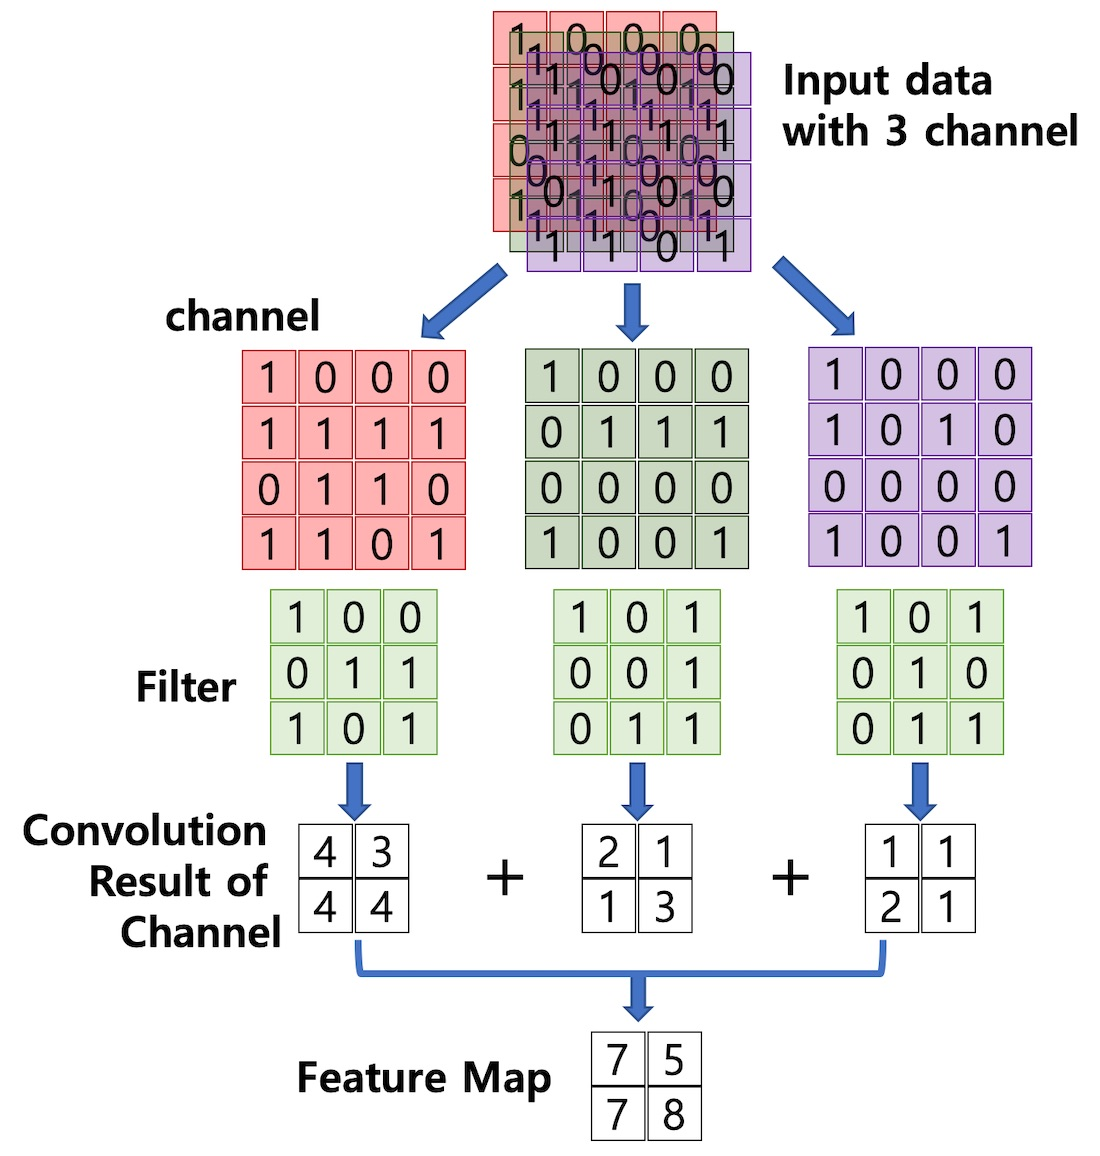

- Black and white images can be expressed as a two-dimensional array
- Color images are composed of RGB (red, green, blue) channels, so one image is displayed as a three-dimensional array.
- In order to perform convolution on inputs with depth, the kernel must also have depth (must be composed of 3 dimensions)
    - The depth of the kernel array is always equal to the depth of the input.
    
- No matter how many dimensions the input or filter has, the output is always a single value.
- Keras’ convolutional layer is basically adapted to 3D input.
    - Black and white images are converted to a 3D array with a depth dimension of 1 and delivered.